In [ ]:
# This Google Colab notebook demonstrates how you might load and plot ecg samples in Assignment 3
# The samples have been made available as numpy multi-dimensional array


In [ ]:
# Install necessary packages and import libraries
!pip install wfdb
!pip install ecg-plot
!pip install neurokit2


In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd
import ecg_plot
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

# Some ECG plotting routines

def plot_combined_ecg(ecg, sample_rate, title):
    """
    Plot a combined 12-lead ECG layout from a PTB-XL ECG sample.
    This function reorders the ECG segments to match a 4-row print format and overlays lead labels.

    Parameters:
    - ecg: numpy array (n_samples x 12), ECG signal
    - fields: metadata dictionary from wfdb.rdsamp  ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    - lead_names: list of original lead names
    - sample_rate: sampling rate of the ECG signal (e.g., 100 or 500 Hz)
    """

    # Get the total number of samples
    n = ecg.shape[0]

    # Quarter marks to split ECG signal into 4 equal time segments
    q1, q2, q3 = n // 4, n // 2, 3 * n // 4

    # Create new leads for each row of the standard layout
    # First row: Lead I, aVR, V1, V4
    lead_I_new = np.concatenate([ecg[0:q1, 0], ecg[q1:q2, 3], ecg[q2:q3, 6], ecg[q3:n, 9]])

    # Second row: Lead II, aVL, V2, V5
    lead_II_new = np.concatenate([ecg[0:q1, 1], ecg[q1:q2, 4], ecg[q2:q3, 7], ecg[q3:n, 10]])

    # Third row: Lead III, aVF, V3, V6
    lead_III_new = np.concatenate([ecg[0:q1, 2], ecg[q1:q2, 5], ecg[q2:q3, 8], ecg[q3:n, 11]])

    # Bottom row (reference): Full Lead II
    lead_IV_new = ecg[:, 1]

    # Stack the 4 new rows (each as a separate lead)
    ecg_new = np.stack([lead_I_new, lead_II_new, lead_III_new, lead_IV_new], axis=1).transpose()

    # Define new lead labels
    lead_names_new = ['I', 'II', 'III', 'II Ref']

    # Plot ECG using ecg_plot library
    ecg_plot.plot(ecg_new, sample_rate=sample_rate, title=title, columns=1, lead_index=lead_names_new)

    # Grab axis from current figure
    ax = plt.gca()

    # Hide tick labels on vertical axis (but keep the ticks)
    ax.set_yticklabels([])

    # Format x-axis labels: only show ticks at integer seconds
    xlabels = ax.get_xticks()
    new_labels = [f"{int(x)}s" if x % 1 == 0 and x <= 10 else "" for x in xlabels]
    ax.set_xticklabels(new_labels)

    # Add annotations for the original leads contributing to each row
    ax.text(2.5, -0.75, 'aVR', fontsize=8, color='black')
    ax.text(2.5, -3.5, 'aVL', fontsize=8, color='black')
    ax.text(2.5, -6.5, 'aVF', fontsize=8, color='black')

    ax.text(5, -0.75, 'V1', fontsize=8, color='black')
    ax.text(5, -3.5, 'V2', fontsize=8, color='black')
    ax.text(5, -6.5, 'V3', fontsize=8, color='black')

    ax.text(7.5, -0.75, 'V4', fontsize=8, color='black')
    ax.text(7.5, -3.5, 'V5', fontsize=8, color='black')
    ax.text(7.5, -6.5, 'V6', fontsize=8, color='black')

    # Add display information for ECG scale and sampling
    ax.text(0.1, -10.4, f'{sample_rate} Hz   25.0 mm/s   10.0mm/mV', fontsize=10, color='black')

    # Display the plot
    ecg_plot.show()

def plot_ecg_with_grid(time, signal, title, sampling_rate, show_grid=True, style='color'):
    """Plots ECG signal with a grid resembling ECG paper."""
    fig, ax = plt.subplots(figsize=(12, 4))  # Adjust figure height as needed
    if (style == 'bw'):
        color_major = (0.4, 0.4, 0.4)
        color_minor = (0.75, 0.75, 0.75)
        color_line  = (0, 0, 0)
    else:
        color_major = (1, 0, 0)
        color_minor = (1, 0.7, 0.7)
        color_line  = (0, 0, 0.7)

    ax.plot(time, signal, color=color_line)
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (mV)')

    if(show_grid):
        scale_ms_per_div = 0.2  # Corresponds to 5 small squares at 25 mm/s
        scale_mV_per_div = 0.5  # Corresponds to 5 small squares at 10 mm/mV

        x_min, x_max = np.min(time), np.max(time)
        y_min, y_max = np.min(signal), np.max(signal)

        ax.set_xticks(np.arange(x_min, x_max, scale_ms_per_div))
        ax.set_yticks(np.arange(y_min, y_max, scale_mV_per_div))

        ax.minorticks_on()
        ax.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))

        # Format x-axis labels to show only integers
        def format_x_ticks(val, pos):
            if np.isclose(val, np.round(val)):
                return f'{int(round(val))}'
            else:
                return ''

        ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))

        display_factor = 1  # Adjust if needed for line widths

        ax.grid(which='major', linestyle='-', linewidth=0.5 * display_factor, color=color_major, alpha=0.5)
        ax.grid(which='minor', linestyle='-', linewidth=0.25 * display_factor, color=color_minor, alpha=0.5)

    ax.set_ylim(y_min - 0.2 * (y_max - y_min), y_max + 0.2 * (y_max - y_min)) # Add some padding
    ax.set_xlim(x_min, x_max)
    plt.show()

def load_numpy_binary_and_plot_separate(input_filename="ecg_data.npy", sampling_rate=100):
    """
    Loads an ECG sample from a binary .npy file and plots each of the 12 leads
    as a separate figure using plot_ecg_with_grid.

    Args:
        input_filename (str): The name of the input .npy file.
        sampling_rate (int): The sampling rate of the ECG data.
    """
    try:
        loaded_ecg_data = np.load(input_filename)
        num_leads, num_samples = loaded_ecg_data.shape
        time = np.linspace(0, num_samples / sampling_rate, num_samples, endpoint=False)

        for i in range(num_leads):
            title = f"Lead {i+1}"
            plot_ecg_with_grid(time, loaded_ecg_data[i, :], title, sampling_rate=sampling_rate)

    except FileNotFoundError:
        print(f"Error: Could not find file '{input_filename}'")
    except Exception as e:
        print(f"An error occurred while loading and plotting: {e}")

def load_numpy_binary_and_plot_combined(input_filename="ecg_data.npy", sampling_rate=100, title="Combined 12-Lead ECG"):
    """
    Loads an ECG sample from a binary .npy file and plots a combined 12-lead ECG
    layout using the provided plot_combined_ecg function.

    Args:
        input_filename (str): The name of the input .npy file.
        sampling_rate (int): The sampling rate of the ECG data.
        title (str): The title of the combined ECG plot.
    """
    try:
        loaded_ecg_data = np.load(input_filename)
        # Transpose back to (n_samples x 12) for plot_combined_ecg
        ecg_for_combined = loaded_ecg_data.T
        plot_combined_ecg(ecg_for_combined, sampling_rate, title)

    except FileNotFoundError:
        print(f"Error: Could not find file '{input_filename}'")
    except Exception as e:
        print(f"An error occurred while loading and plotting the combined ECG: {e}")

(12, 1000)


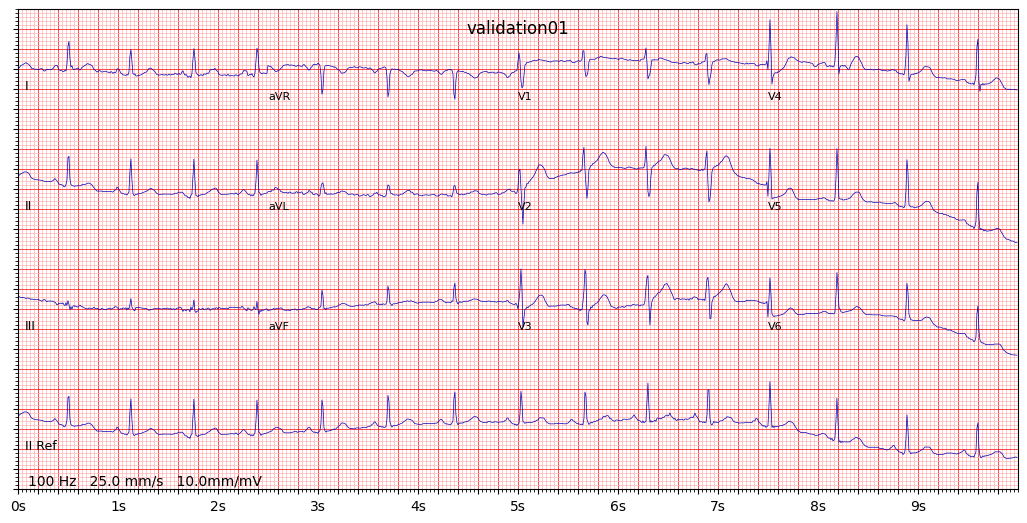

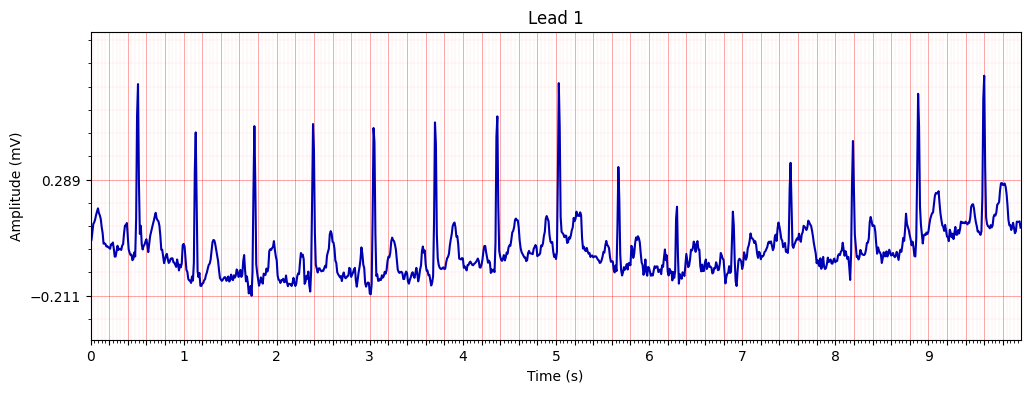

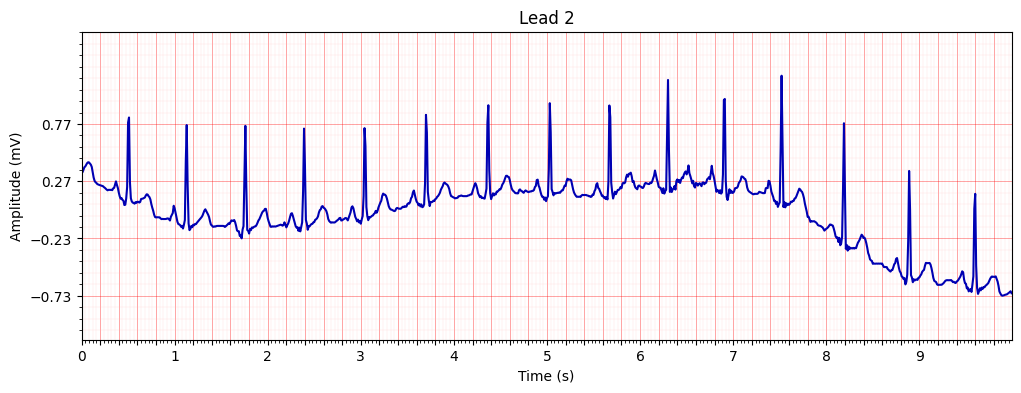

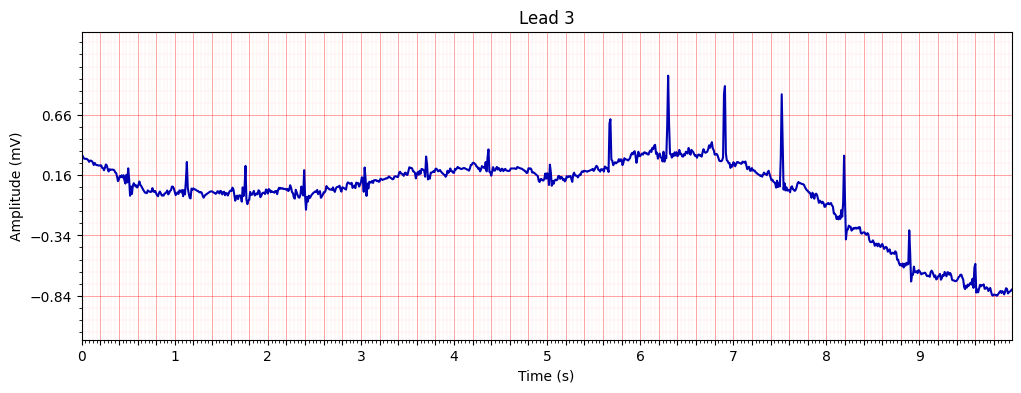

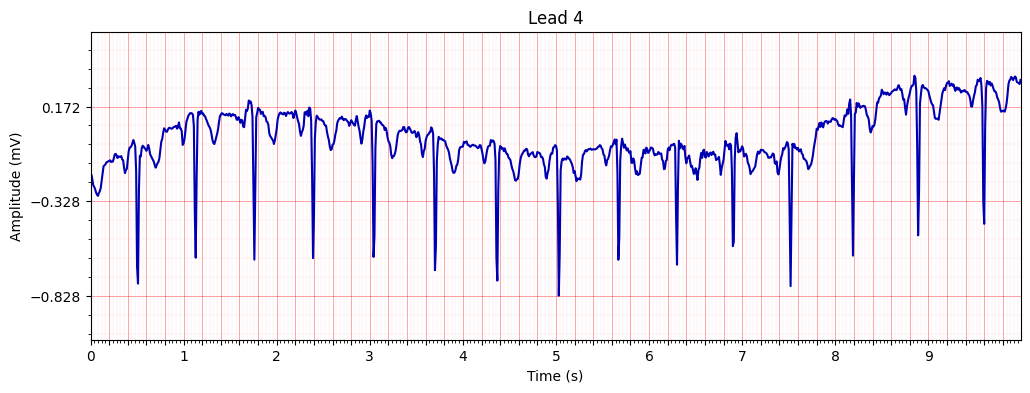

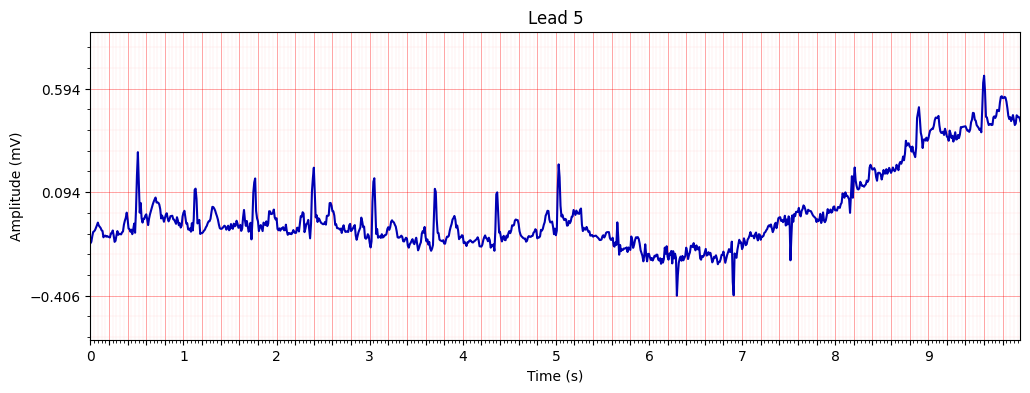

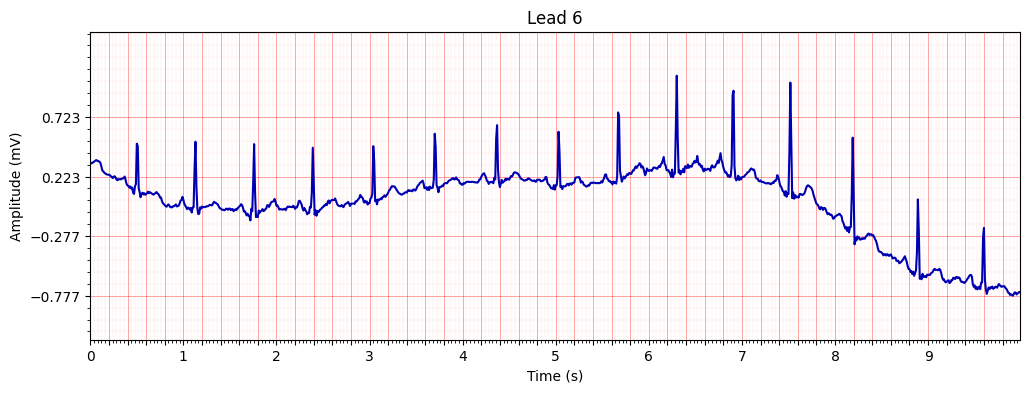

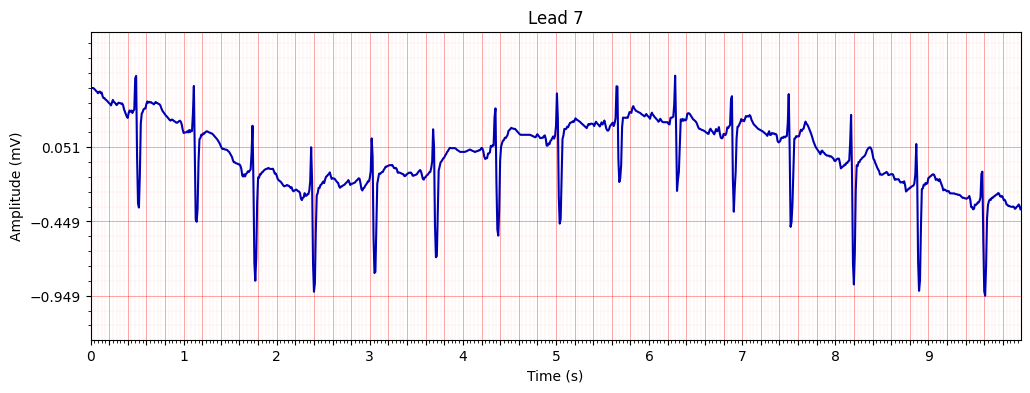

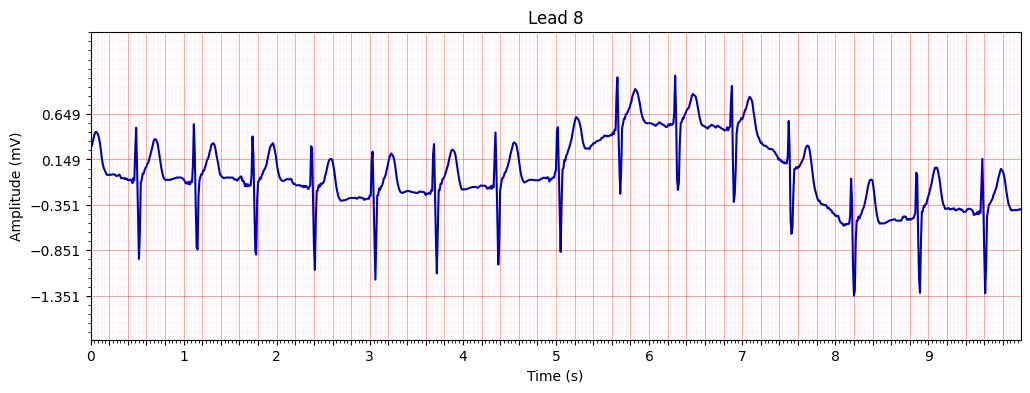

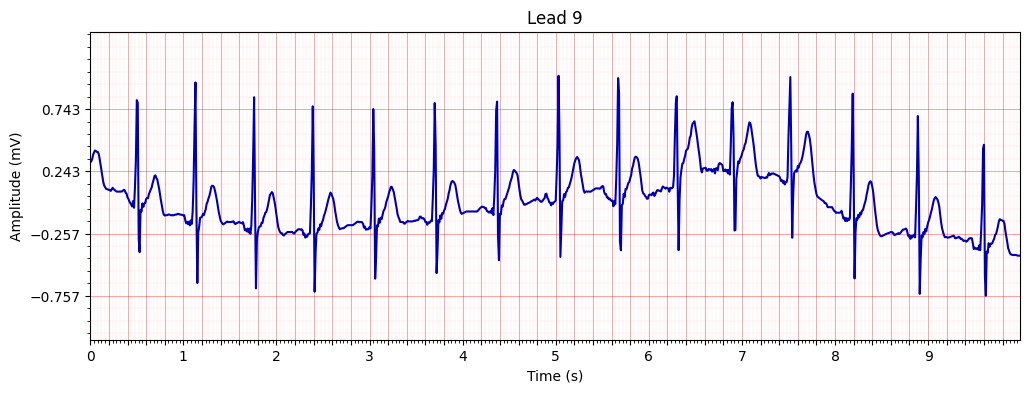

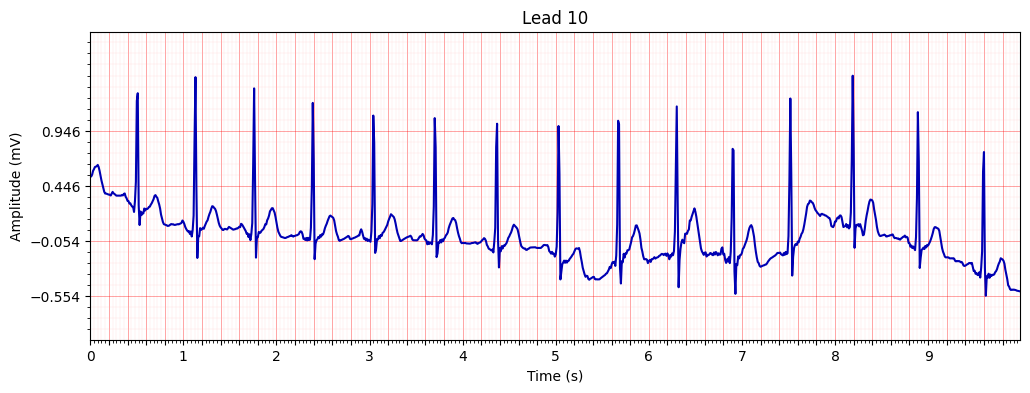

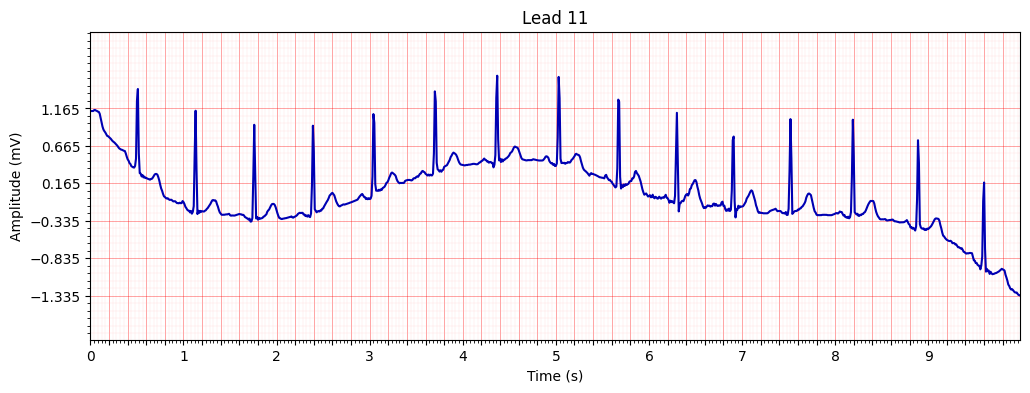

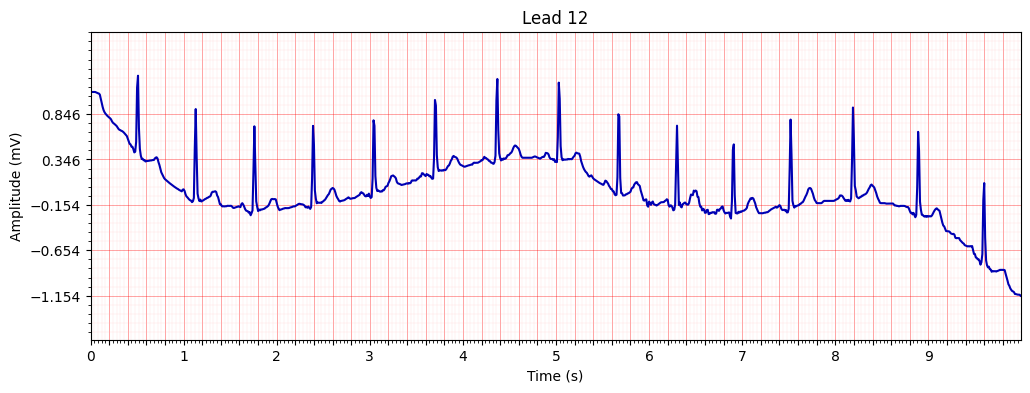

In [ ]:
# Let's load validation01 and plot it
# In python, it is as simple as calling np.load(filename)
# When loaded, the data is a 12x1000 2D array
# The order of the leads is I II III aVR aVL aVF V1 V2 V3 V4 V5 V6

# Load the numpy data for AI models to predict/diagnose
data = np.load("validation01.npy")
print(data.shape)

# Load an *npy file and plot the leads altogether on a figure
load_numpy_binary_and_plot_combined(input_filename="validation01.npy", title="validation01")

# Load an *npy file and plot the leads separately
load_numpy_binary_and_plot_separate(input_filename="validation01.npy")